# 🏥 Healthcare Patient Flow & Patient Experience Analytics

## 📌 Project Overview

Healthcare organizations continuously strive to improve operational efficiency and patient experience. One of the most critical aspects of hospital operations is understanding patient flow, waiting times, admission patterns, and patient satisfaction.

This project analyzes patient flow data to identify operational bottlenecks, understand patient demographics, evaluate admission patterns, and explore the relationship between waiting time and patient satisfaction.

### Tools Used

- Python (Pandas, NumPy, Matplotlib, Seaborn)
- MySQL
- Google Looker Studio

### Skills Demonstrated

- Data Cleaning
- Data Quality Assessment
- Feature Engineering
- Exploratory Data Analysis (EDA)
- Business Analytics
- SQL Analysis
- Dashboard Development
- Data Visualization
- Healthcare Analytics

---

# 🎯 Business Problem

Healthcare providers need to answer several operational questions:

- When are the busiest admission periods?
- Which patient groups experience the longest waiting times?
- Which patients are more likely to be admitted?
- Which referral departments create operational bottlenecks?
- Does waiting time impact patient satisfaction?

Understanding these patterns can help hospitals improve resource allocation, reduce waiting times, and enhance patient experience.

---

# 📂 Dataset Information

### Dataset

**Healthcare Analytics Patient Flow Data**

### Source

https://www.kaggle.com/datasets/hassanjameelqureshi/healthcare-analytics-patient-flow-data

### Dataset Description

The dataset contains patient admission and operational information including:

| Column | Description |
|----------|-------------|
| Patient Id | Unique patient identifier |
| Patient Admission Date | Date of admission |
| Patient Admission Time | Time of admission |
| Merged | Patient name |
| Patient Gender | Patient gender |
| Patient Age | Patient age |
| Patient Race | Patient race |
| Department Referral | Referred department |
| Patient Admission Flag | Admission status |
| Patient Satisfaction Score | Satisfaction survey score |
| Patient Waittime | Patient waiting time |

---

# 🔄 Project Workflow

```text
Raw Dataset
    ↓
Data Understanding
    ↓
Data Quality Assessment
    ↓
Data Cleaning
    ↓
Feature Engineering
    ↓
Exploratory Data Analysis
    ↓
Business Analysis
    ↓
Dashboard Development
    ↓
Insights & Recommendations
```


# 📊 Step 1 — Import Libraries

The first step is importing all libraries required for data manipulation, visualization, and analysis.

Libraries used:

- Pandas
- NumPy
- Matplotlib
- Seaborn

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 📊 Step 2 — Load Dataset

The dataset is loaded into a Pandas DataFrame.

Objectives:

- Verify successful import
- Review sample records
- Confirm dataset structure

In [2]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))
import kagglehub

/kaggle/input/datasets/hassanjameelahmed/healthcare-analytics-patient-flow-data/healthcare_analytics_patient_flow_data.csv


In [3]:
df = pd.read_csv('/kaggle/input/datasets/hassanjameelahmed/healthcare-analytics-patient-flow-data/healthcare_analytics_patient_flow_data.csv')
df.head()

,Patient Id,Patient Admission Date,Patient Admission Time,Merged,Patient Gender,Patient Age,Patient Race,Department Referral,Patient Admission Flag,Patient Satisfaction Score,Patient Waittime
0,780-96-6113,9/9/2024,9:25:00 AM,W. Breede,Female,63,African American,NaN,Not Admission,5.0,32
1,714-35-6722,9/9/2024,4:42:00 PM,Y. Baldetti,Male,31,Asian,Orthopedics,Not Admission,NaN,22
2,571-85-3714,9/9/2024,12:14:00 AM,M. Semerad,Male,75,White,General Practice,Not Admission,NaN,16
3,404-43-9499,9/9/2024,8:33:00 PM,K. Blaydes,Male,79,African American,General Practice,Admission,NaN,38
4,552-51-5855,9/9/2024,7:25:00 PM,F. Dickerson,Female,24,African American,NaN,Admission,NaN,36


# 📊 Step 3 — Data Understanding

Before performing any cleaning process, it is important to understand the dataset.

Activities performed:

- Check dataset dimensions
- Review column names
- Inspect data types
- Generate descriptive statistics

Questions answered:

- How many records exist?
- What variables are available?
- Which fields are categorical or numerical?

In [4]:
# DATASET SHAPE
print(df.shape)

(9216, 11)


In [5]:
#COLUMN LIST
df.columns

Index(['Patient Id', 'Patient Admission Date', 'Patient Admission Time',
       'Merged', 'Patient Gender', 'Patient Age', 'Patient Race',
       'Department Referral', 'Patient Admission Flag',
       'Patient Satisfaction Score', 'Patient Waittime'],
      dtype='object')

In [6]:
#DATA TYPES
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9216 entries, 0 to 9215
Data columns (total 11 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   Patient Id                  9216 non-null   object 
 1   Patient Admission Date      9216 non-null   object 
 2   Patient Admission Time      9216 non-null   object 
 3   Merged                      9216 non-null   object 
 4   Patient Gender              9216 non-null   object 
 5   Patient Age                 9216 non-null   int64  
 6   Patient Race                9216 non-null   object 
 7   Department Referral         3816 non-null   object 
 8   Patient Admission Flag      9216 non-null   object 
 9   Patient Satisfaction Score  2517 non-null   float64
 10  Patient Waittime            9216 non-null   int64  
dtypes: float64(1), int64(2), object(8)
memory usage: 792.1+ KB


# 📊 Step 4 — Data Quality Assessment

Data quality assessment ensures reliable analysis results.

### Missing Value Analysis

Missing values were identified and quantified for all columns.

There are High Missing Values in:

- Department Referral
- Patient Satisfaction Score

So special attention was given.

In [7]:
# Missing values analysis in percentage
missing = pd.DataFrame({
    'Missing Count' : df.isnull().sum(),
    'Missing Percentage' : round(df.isnull().sum()/len(df)*100,2)
})
missing.sort_values('Missing Percentage', ascending = False)

,Missing Count,Missing Percentage
Patient Satisfaction Score,6699,72.69
Department Referral,5400,58.59
Patient Id,0,0.00
Patient Admission Time,0,0.00
Patient Admission Date,0,0.00
Merged,0,0.00
Patient Gender,0,0.00
Patient Race,0,0.00
Patient Age,0,0.00
Patient Admission Flag,0,0.00


### Duplicate Analysis

Duplicate records were checked and evaluated.

In [8]:
print(df.duplicated().sum())
# If theres any, remove duplicate
df = df.drop_duplicates()

0


### Data Consistency Check

Categorical variables were inspected for inconsistent values.

Example:

'Femaleemale'
in Patient Gender.

This value was identified as a typo and corrected.


In [9]:
df['Patient Gender'].value_counts()

Patient Gender
Male           4729
Female         4470
Femaleemale      17
Name: count, dtype: int64

# 🧹 Step 5 — Data Cleaning

Several cleaning procedures were applied.

### Gender Standardization

Corrected inconsistent gender values.

In [10]:
df['Patient Gender'] = (
    df['Patient Gender']
    .replace('Femaleemale', 'Female') #fix the typo to 'Female'
)
df['Patient Gender'].value_counts()

Patient Gender
Male      4729
Female    4487
Name: count, dtype: int64

### Department Referral Handling

Missing referral values were replaced with:

```text
No Referral
```

Insight : The gender distribution in this data is balanced.

In [11]:
df['Department Referral'] = (
    df['Department Referral']
    .fillna('No Referral') #Fill missing values with 'No Referral'
    )

### Satisfaction Score Handling

Due to the high percentage of missing values, no imputation was performed.

Analyses involving satisfaction scores only considered available responses.

In [12]:
df['Satisfaction_Provided'] = (
    df['Patient Satisfaction Score']
    .notna()
)


# ⚙️ Step 6 — Feature Engineering

Several additional variables were created to support business analysis.

### Admission Datetime

Combined admission date and time into a single timestamp.

In [13]:
# Create Datetime
df['Admission_Datetime'] = (
    pd.to_datetime (
        df['Patient Admission Date'] + ' ' +
        df['Patient Admission Time'],
        format='%d/%m/%Y %I:%M:%S %p'
    )
)

### Admission Hour

Extracted admission hour.

Purpose:

- Peak hour analysis

In [14]:
df['Admission_Hour'] = (
    df['Admission_Datetime']
    .dt.hour
)

### Admission Day

Extracted day of week.

Purpose:

- Busiest day analysis

In [15]:
df['Admission_Day'] = (
    df['Admission_Datetime']
    .dt.day_name()
)

### Admission Month

Extracted month.

Purpose:

- Monthly trend analysis

In [16]:
df['Admission_Month'] = (
    df['Admission_Datetime']
    .dt.month_name()
)

### Age Group

Patients were segmented into:

| Age Group | Age Range |
|------------|------------|
| Child | < 18 |
| Young Adult | 18 - 39 |
| Adult | 40 - 59 |
| Senior | 60+ |

Purpose:

- Demographic analysis
- Admission analysis
- Wait time analysis

In [17]:
def age_group(age) :
  if age < 18 :
    return 'Child'
  elif age < 40 :
    return 'Young Adult'
  elif age < 60 :
    return 'Adult'
  else :
    return 'Senior'

df['Age_Group'] = (
    df['Patient Age']
    .apply(age_group)
)

### Admission Binary

Created binary admission indicator:

```text
Admission = 1
Not Admission = 0
```

Purpose:

- Admission rate calculations


In [18]:
df['Admission_Binary'] = (
    df['Patient Admission Flag']
    .eq('Admission')
    .astype(int)
)

# 📈 Step 7 — Exploratory Data Analysis (EDA)

EDA was conducted to understand overall patient behavior and operational patterns.

### Age Distribution

Objective:

Identify dominant patient age groups.

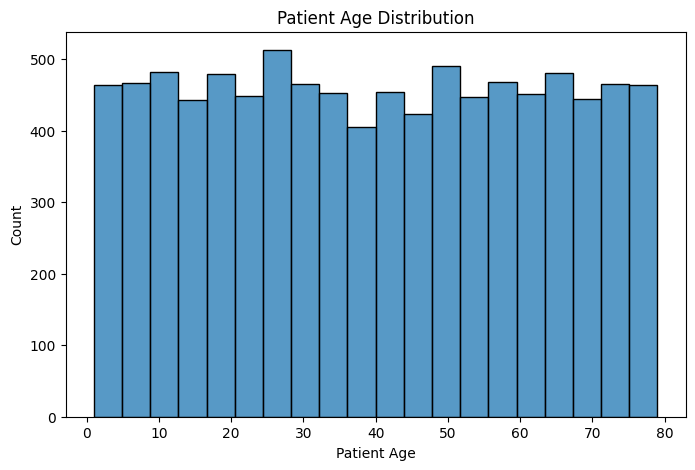

In [19]:
plt.figure(figsize=(8,5))

sns.histplot(
    df['Patient Age'],
    bins=20
)

plt.title('Patient Age Distribution')

plt.show()

### Waiting Time Distribution

Objective:

Understand waiting time patterns and variability.

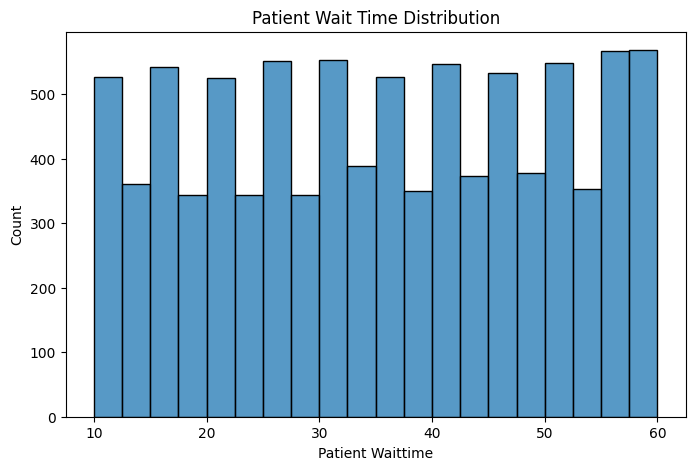

In [20]:
df['Patient Waittime'].describe()

plt.figure(figsize=(8,5))

sns.histplot(
    df['Patient Waittime'],
    bins=20
)

plt.title('Patient Wait Time Distribution')

plt.show()

### Gender Distribution

Objective:

Understand gender composition.

<Axes: xlabel='Patient Gender'>

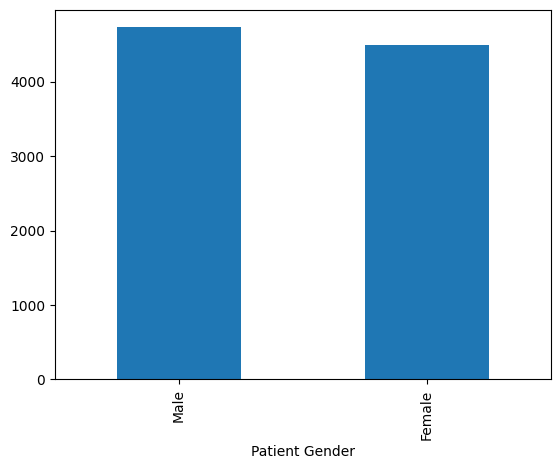

In [21]:
df['Patient Gender']\
.value_counts()\
.plot(kind='bar')

Insight : The gender distribution in this data is balanced.

### Race Distribution

Objective:

Analyze patient demographic diversity.

<Axes: xlabel='Patient Race'>

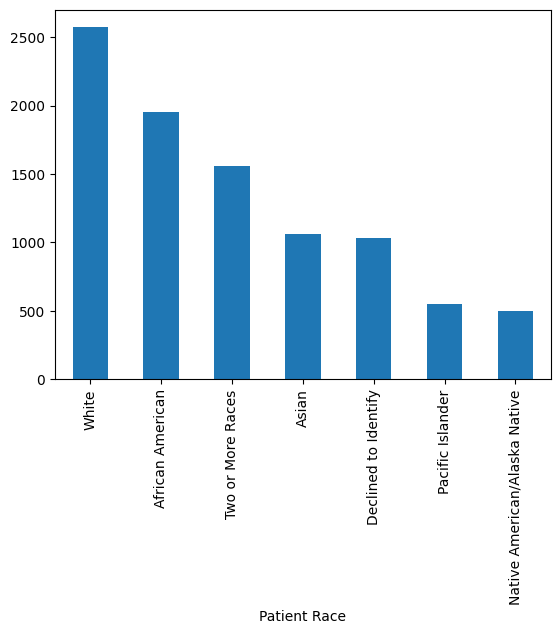

In [22]:
df['Patient Race']\
.value_counts()\
.plot(kind='bar')

# 📊 Step 8 — Business Analysis

Several business-oriented analyses were conducted in MySQL.

## Establish Key Performance Indicator (KPI)
1. Total Patients
2. Average Waittime
3. Admission Rate
4. Average Satisfaction Score
5. Survey Response Rate

## Patient Volume Analysis

Questions:

- What are the busiest admission hours?
- What are the busiest days?
- Are there monthly trends in patient volume?

---

## Demographic Analysis

Questions:

- Which age groups visit most frequently?
- What is the gender distribution?
- What is the racial distribution?

---

## Wait Time Analysis

Questions:

- Which age groups wait the longest?
- Are there wait time differences by gender?
- Which departments have the highest waiting times?

---

## Admission Analysis

Questions:

- Which age groups have the highest admission rates?
- Does admission vary by gender?
- Which referral departments are associated with higher admission rates?

---

## Patient Experience Analysis

Questions:

- Which groups report the highest satisfaction?
- Is patient satisfaction associated with waiting time?


All of those were analyzed and performed by using SQL :

### BUSINESS ANALYSIS IN SQL

#### KPI 1 : TOTAL PATIENTS
```text
SELECT COUNT(*) AS total_patients
FROM patient_flow;
```

#### KPI 2 : AVERAGE WAIT TIME
```text
SELECT ROUND(AVG(patient_waittime),2) 
AS avg_wait_time
FROM patient_flow;
```
#### KPI 3 : ADMISSION RATE
```text
SELECT
ROUND(AVG(Admission_Binary)*100,2)
AS admission_rate_pct
FROM patient_flow;
```
#### KPI 4 : AVERAGE SATISFACTION SCORE
```text
SELECT
ROUND(AVG(patient_satisfaction_score),2)
AS avg_satisfaction_score
FROM patient_flow
WHERE patient_satisfaction_score IS NOT NULL;
```
#### KPI 5 : SURVEY RESPONSE RATE
```text
SELECT
ROUND(
    SUM(CASE 
        WHEN patient_satisfaction_score IS NOT NULL 
        AND TRIM(patient_satisfaction_score) != '' 
        THEN 1 ELSE 0 
    END) 
    * 100.0 / COUNT(*)
, 2) AS surveysatisfaction_response_rate
FROM patient_flow;

SELECT
ROUND(
    SUM(CASE WHEN patient_race = 'Declined to Identify' THEN 0 ELSE 1 END) 
    * 100.0 / COUNT(*)
, 2) AS surveyrace_response_rate
FROM patient_flow;
```
### PATIENT VOLUME ANALYSIS
#### ANALYSIS 1 : Peak Admission Hour
```text
SELECT Admission_Hour,
COUNT(*) AS total_patients
FROM patient_flow
GROUP BY Admission_Hour
ORDER BY total_patients DESC;
```
#### ANALYSIS 2 : Patient Volume by Day
```text
SELECT
Admission_Day,
COUNT(*) AS total_patients
FROM patient_flow
GROUP BY Admission_Day
ORDER BY total_patients DESC;
```
#### ANALYSIS 3 : Patient Volume by Month
```text
SELECT
Admission_Month,
COUNT(*) AS total_patients
FROM patient_flow
GROUP BY Admission_Month
ORDER BY total_patients DESC;
```
### DEMOGRAPHIC ANALYSIS
#### ANALYSIS 4 : Patient Distribution by Gender
```text
SELECT
patient_gender,
COUNT(*) AS total_patients
FROM patient_flow
GROUP BY patient_gender
ORDER BY total_patients DESC;
```
#### ANALYSIS 5  : Patient Distribution By Age Group
```text
SELECT
Age_Group,
COUNT(*) AS total_patients
FROM patient_flow
GROUP BY Age_Group
ORDER BY total_patients DESC;
```
#### ANALYSIS 6 : Patient Distribution By Race
```text
SELECT
patient_race,
COUNT(*) AS total_patients
FROM patient_flow
GROUP BY patient_race
ORDER BY total_patients DESC;
```
### WAIT TIME ANALYSIS
#### ANALYSIS 7 : Average Wait Time by Age Group
```text
SELECT Age_Group,
ROUND(AVG(patient_waittime),2)
AS avg_wait_time
FROM patient_flow
GROUP BY Age_Group
ORDER BY avg_wait_time DESC;
```
#### ANALYSIS 8 : Average Wait Time by Gender
```text
SELECT patient_gender,
ROUND(AVG(patient_waittime),2)
AS avg_wait_time
FROM patient_flow
GROUP BY patient_gender
ORDER BY avg_wait_time DESC;
```
#### ANALYSIS 9 : Average Wait Time by Race
```text
SELECT patient_race,
ROUND(AVG(patient_waittime),2)
AS avg_wait_time
FROM patient_flow
GROUP BY patient_race
ORDER BY avg_wait_time DESC;
```
#### ANALYSIS 10 : Average Wait Time by Referral Department
```text
SELECT department_referral,
ROUND(AVG(patient_waittime),2)
AS avg_wait_time
FROM patient_flow
GROUP BY department_referral
ORDER BY avg_wait_time DESC;
```
### ADMISSION ANALYSIS
#### ANALYSIS 11 : Admission Rate by Age Group
```text
SELECT Age_Group,
ROUND(AVG(Admission_Binary)*100,2)
AS admission_rate_pct
FROM patient_flow
GROUP BY Age_Group
ORDER BY admission_rate_pct DESC;
```
#### ANALYSIS 12 : Admission Rate by Gender
```text
SELECT patient_gender,
ROUND(AVG(Admission_Binary)*100,2)
AS admission_rate_pct
FROM patient_flow
GROUP BY patient_gender
ORDER BY admission_rate_pct DESC;
```
#### ANALYSIS 13 : Admission Rate by Race
```text
SELECT patient_race,
ROUND(AVG(Admission_Binary)*100,2)
AS admission_rate_pct
FROM patient_flow
GROUP BY patient_race
ORDER BY admission_rate_pct DESC;
```
#### ANALYSIS 14 : Admission Rate by Referral Department
```text
SELECT department_referral,
ROUND(AVG(Admission_Binary)*100,2)
AS admission_rate_pct
FROM patient_flow
GROUP BY department_referral
ORDER BY admission_rate_pct DESC;
```
### PATIENT SATISFACTION ANALYSIS
#### ANALYSIS 15 : Satisfaction Score by Age Group
```text
SELECT Age_Group,
ROUND(AVG(patient_satisfaction_score),2)
AS avg_satisfaction
FROM patient_flow
WHERE patient_satisfaction_score IS NOT NULL
GROUP BY Age_Group
ORDER BY avg_satisfaction DESC;
```
#### ANALYSIS 16 : Satisfaction Score by Gender
```text
SELECT patient_gender,
ROUND(AVG(patient_satisfaction_score),2)
AS avg_satisfaction
FROM patient_flow
WHERE patient_satisfaction_score IS NOT NULL
GROUP BY patient_gender
ORDER BY avg_satisfaction DESC;
```
#### ANALYSIS 17 : Satisfaction Score by Referral Department
```text
SELECT department_referral,
ROUND(AVG(patient_satisfaction_score),2)
AS avg_satisfaction
FROM patient_flow
WHERE patient_satisfaction_score IS NOT NULL
GROUP BY department_referral
ORDER BY avg_satisfaction DESC;
```
### ADVANCED ANALYSIS
#### ANALYSIS 18 : Admission Rate by Age Group and Gender
```text
SELECT
Age_Group,
patient_gender,
ROUND(AVG(Admission_Binary)*100,2)
AS admission_rate_pct
FROM patient_flow
GROUP BY
Age_Group,
patient_gender
ORDER BY admission_rate_pct DESC;
```
#### ANALYSIS 19 : Wait Time by Age Group and Gender
```text
SELECT
Age_Group,
patient_gender,
ROUND(AVG(patient_waittime),2)
AS avg_wait_time
FROM patient_flow
GROUP BY
Age_Group,
patient_gender
ORDER BY avg_wait_time DESC;
```
#### ANALYSIS 20 - Referral Utilization
```text
SELECT
department_referral,
COUNT(*) AS total_referrals
FROM patient_flow
GROUP BY department_referral
ORDER BY total_referrals DESC;
```

# 📊 Dashboard Development

An interactive dashboard was developed using **Google Looker Studio**.

### Dashboard Link

👉 https://datastudio.google.com/reporting/5430f687-4fdf-4b55-bb1d-b5a7d66255df


# 🔍 Key Findings


### 1. Low survey response rate may skew satisfaction results
If response rates are low per department, the average satisfaction scores may not reflect true patient experience. Departments with few responses are more vulnerable to outlier feedback, so scores for small-bubble departments like Renal, Neurology, and Gastroenterology should be interpreted with caution. High-volume departments like “No Referral” likely have more representative data.
### 2. Clear trade-off between satisfaction and wait time
Based on current satisfaction score survey, departments with higher average satisfaction scores tend to have longer patient wait times. Gastroenterology, Neurology, and Physiotherapy score highest on satisfaction ∼1.45-1.76 but also have the longest wait times 35.8-37 min.
### 3. “No Referral” dominates patient volume but has mid-low satisfaction
The “No Referral” bubble is the largest, meaning it handles the most patients. However, its avg satisfaction score is only 1.30 and wait time is 35.2 min. High volume + average experience = biggest impact on overall hospital score.
### 4. High-volume departments are fast but not highly rated
General Practice and Orthopedics also have large bubbles. They process patients quickly ∼35 min wait time with moderate satisfaction 1.38-1.40. Efficiency is good, but patient experience can still be improved.
### 5. Low-volume, high-satisfaction outliers exist
Gastroenterology achieves the highest satisfaction 1.76 with a reasonable wait time 35.8 min, but serves fewer patients. This suggests best practices could be replicated.
### 6. Renal has the lowest satisfaction and low volume
Renal scores lowest at 1.21 with the smallest bubble and short wait time 34.7 min. Low wait time isn’t translating to patient satisfaction, indicating other service factors need review.

# 💡 Recommendations
### 1. Improve and monitor survey response rates by department
Target ≥30% response rate per department as a minimum threshold for reliability. Strategies:Send SMS/WhatsApp survey links at discharge when experience is freshUse QR codes on receipts/bedside cards for instant feedback Train staff to explain “1-minute survey helps us serve you better” to boost participationShow response rate % on the same bubble chart using bubble border thickness or color opacity. Faded bubbles = low confidence
### 2. Weight results or add confidence intervals until response rates improve
While response rates are low, use weighted satisfaction scores based on patient volume, or add error bars/“n=xx” labels to each bubble. This prevents overreacting to scores from departments with only 5-10 responses.
### 3. Prioritize “No Referral” for improvement initiatives
Since this group represents the largest patient base, even small gains in satisfaction here will lift overall hospital metrics. Focus on non-wait-time factors: communication, discharge process, staff courtesy.
### 4. Replicate Gastroenterology’s practices
Benchmark what Gastroenterology does differently to achieve 1.76 satisfaction. Document SOPs, staff training, or patient communication methods and pilot them in high-volume departments like GP and Orthopedics.
### 5. Address wait time in Neurology & Physiotherapy
Patients are satisfied despite 36.5-37 min waits, but long waits cap scalability. Review scheduling, triage, and resource allocation to reduce wait time without dropping satisfaction.
### 6. Investigate root cause for low Renal satisfaction
Short wait time but lowest score suggests issues beyond speed. Conduct patient feedback analysis on staff interaction, clarity of treatment, or facility factors specific to Renal.
### 7. Use the quadrant view to set targets
Set targets to move all departments toward the “bottom-right” quadrant: high satisfaction >1.5 and wait time <36 min. Track progress monthly using the same bubble chart.

# ✅ Conclusion

This project demonstrates a complete end-to-end healthcare analytics workflow, covering data cleaning, feature engineering, exploratory analysis, business analysis, and dashboard development.

The findings provide actionable insights that can support operational decision-making, optimize patient flow, and improve patient experience within healthcare facilities.